# 01 — U.S. Rate Environment (2023–2026)

Exploratory analysis of the Treasury yield curve and key benchmark rates over the current rate cycle. This covers the Fed's hiking campaign, the peak plateau, and the early cutting phase — the most volatile rate environment in decades.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

curve = pd.read_csv('../data/daily_treasury_yield_curve.csv', parse_dates=['date'], index_col='date')
features = pd.read_csv('../data/model_features_daily.csv', parse_dates=['date'], index_col='date')

print(f"Date range : {curve.index.min().date()}  →  {curve.index.max().date()}")
print(f"Trading days: {len(curve)}")

Date range : 2023-01-03  →  2026-04-22
Trading days: 826


## Key Benchmark Rates

SOFR is the dominant overnight rate for repo and securities financing. The 2Y Treasury tracks Fed expectations; the 10Y is the benchmark for duration and long-term pricing.

/var/folders/xy/97gdb2gs1nj17qvw98v64sq80000gn/T/ipykernel_2131/2061036288.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


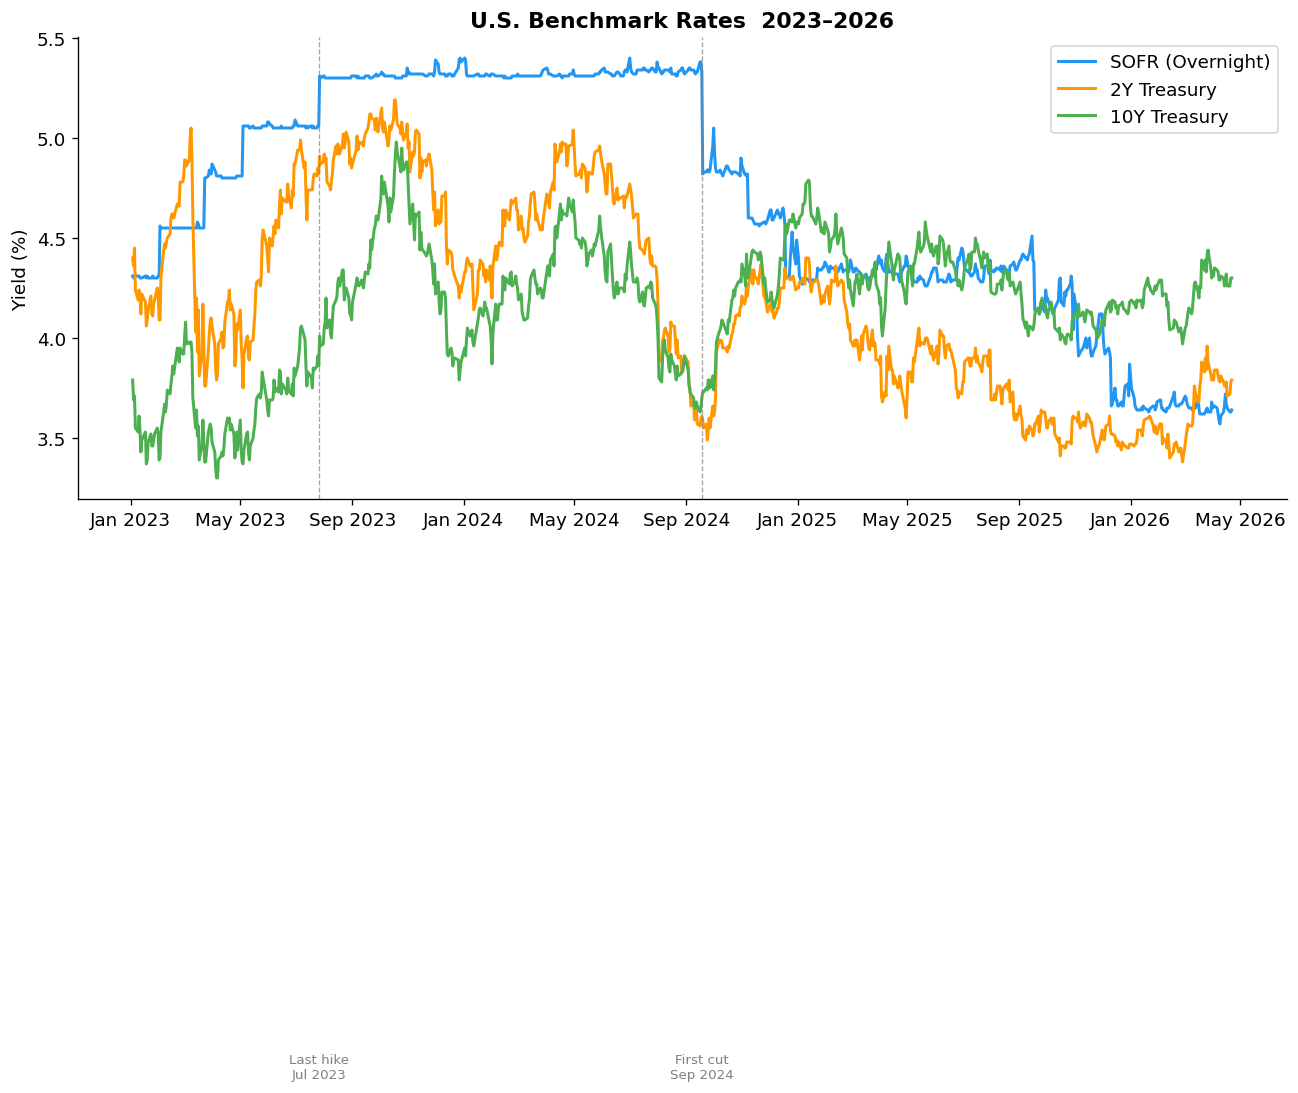

In [2]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(features['fred_sofr'],  label='SOFR (Overnight)',  linewidth=1.8, color='#2196F3')
ax.plot(curve['2_yr'],          label='2Y Treasury',       linewidth=1.8, color='#FF9800')
ax.plot(curve['10_yr'],         label='10Y Treasury',      linewidth=1.8, color='#4CAF50')

# Fed pivot annotations
ax.axvline(pd.Timestamp('2023-07-26'), color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(pd.Timestamp('2024-09-18'), color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
ax.text(pd.Timestamp('2023-07-26'), 0.3, 'Last hike\nJul 2023', fontsize=8, color='grey', ha='center')
ax.text(pd.Timestamp('2024-09-18'), 0.3, 'First cut\nSep 2024', fontsize=8, color='grey', ha='center')

ax.set_title('U.S. Benchmark Rates  2023–2026', fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../images/01_benchmark_rates.png', dpi=120, bbox_inches='tight')
plt.show()

## Yield Curve Inversion

The 10Y–2Y spread is a widely watched recession indicator and a key driver of deposit and lending margins. An inverted curve compresses net interest income across the industry.

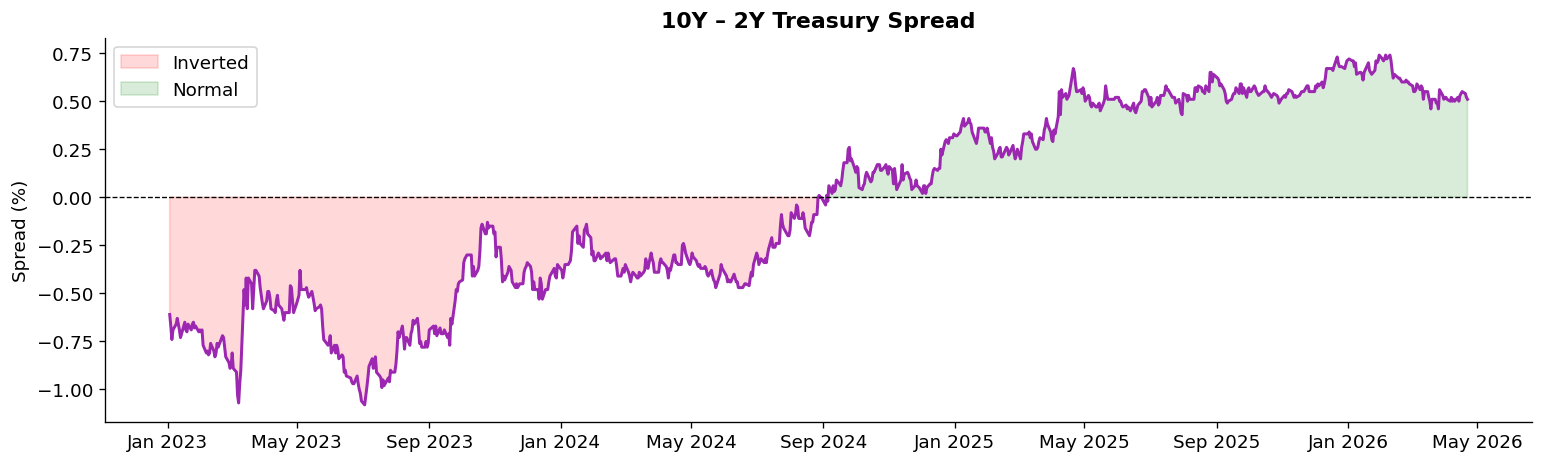

Curve inverted for 416 of 826 trading days (50%)


In [3]:
spread = curve['10_yr'] - curve['2_yr']

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(spread, linewidth=1.8, color='#9C27B0')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(spread.index, spread, 0, where=(spread < 0), alpha=0.15, color='red', label='Inverted')
ax.fill_between(spread.index, spread, 0, where=(spread >= 0), alpha=0.15, color='green', label='Normal')

ax.set_title('10Y – 2Y Treasury Spread', fontweight='bold')
ax.set_ylabel('Spread (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig('../images/01_yield_curve_spread.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Curve inverted for {(spread < 0).sum()} of {len(spread)} trading days ({(spread < 0).mean():.0%})")

## Yield Curve Shape Over Time

Comparing the curve at three key moments shows how dramatically the shape shifted — from deeply inverted during peak Fed tightening to a more normal upward slope as cuts began.

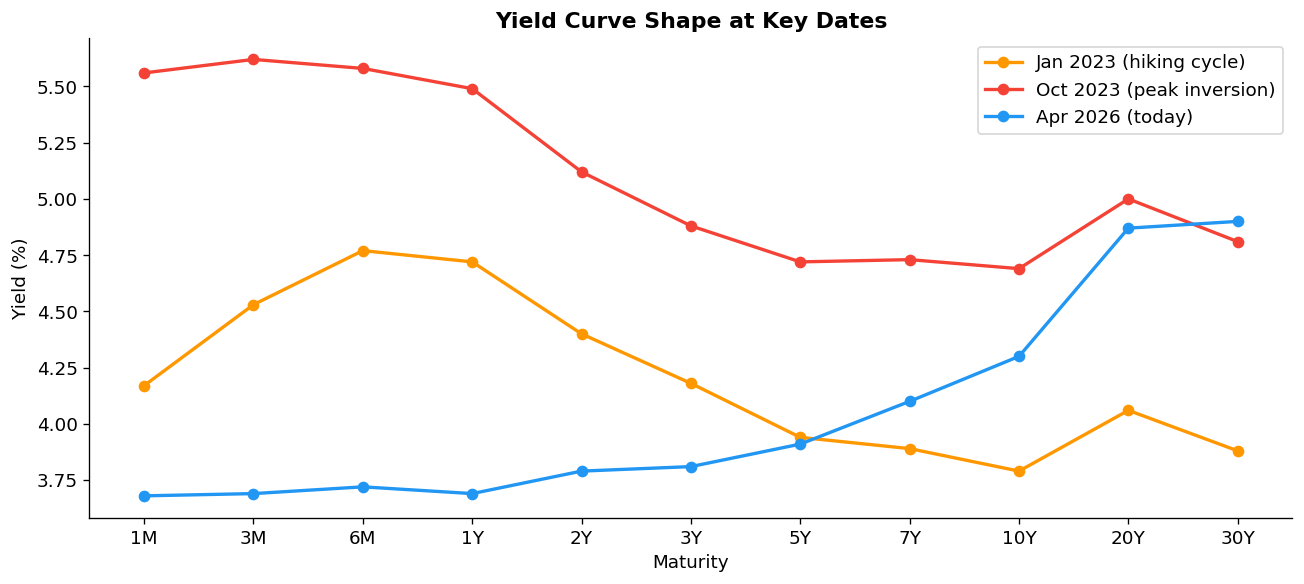

In [4]:
tenor_cols  = ['1_mo', '3_mo', '6_mo', '1_yr', '2_yr', '3_yr', '5_yr', '7_yr', '10_yr', '20_yr', '30_yr']
tenor_labels = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

dates = {
    'Jan 2023 (hiking cycle)':  '2023-01-03',
    'Oct 2023 (peak inversion)': '2023-10-02',
    'Apr 2026 (today)':          curve.index.max().strftime('%Y-%m-%d'),
}
colors = ['#FF9800', '#F44336', '#2196F3']

fig, ax = plt.subplots(figsize=(11, 5))
for (label, date), color in zip(dates.items(), colors):
    row = curve.loc[date, tenor_cols]
    ax.plot(tenor_labels, row.values, marker='o', linewidth=2, label=label, color=color)

ax.set_title('Yield Curve Shape at Key Dates', fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.set_xlabel('Maturity')
ax.legend()
plt.tight_layout()
plt.show()